# 03: Campaign Impact Analysis
This notebook evaluates how Wikimedia campaigns (Fundraising, Wiki Loves Monuments, etc.) influence Wikipedia usage behavior using an event-study framework.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import json
from datetime import timedelta

# Add src to path
sys.path.append(os.path.abspath('../../'))
from src.data_prep import clean_pageview_data, add_time_features

# Configuration
DATA_PATH = '../../data/raw/en_wiki_pageviews_daily.csv'
CONFIG_PATH = '../../config/campaign_dates.json'
REPORT_DIR = '../../reports/'
os.makedirs(REPORT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

## 1. Load Data and Configuration

In [3]:
# Load pageviews
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = clean_pageview_data(df)
df = add_time_features(df)

# Load campaign dates
with open(CONFIG_PATH, 'r') as f:
    campaign_config = json.load(f)

print(f"Data loaded from {DATA_PATH}")
print(f"Campaign types found: {list(campaign_config.keys())}")

Data loaded from ../../data/raw/en_wiki_pageviews_daily.csv
Campaign types found: ['fundraising', 'wiki_loves_monuments', 'wikipedia_asian_month', 'wiki_loves_earth']


## 2. Event Study Function
We will define a function to analyze a single campaign instance using an estimation window and an event window.

In [4]:
def analyze_campaign(df, start_date, campaign_name, year):
    start_date = pd.to_datetime(start_date)
    
    # Windows
    est_start = start_date - timedelta(days=60)
    est_end = start_date - timedelta(days=31)
    event_start = start_date - timedelta(days=30)
    event_end = start_date + timedelta(days=30)
    
    # Data for windows
    est_data = df[(df['timestamp'] >= est_start) & (df['timestamp'] <= est_end)]
    event_data = df[(df['timestamp'] >= event_start) & (df['timestamp'] <= event_end)].copy()
    
    if est_data.empty or event_data.empty:
        return None
        
    # Baseline: Average per weekday in estimation window
    baseline = est_data.groupby('day_of_week')['views'].mean().to_dict()
    
    # Apply baseline
    event_data['expected_views'] = event_data['day_of_week'].map(baseline)
    event_data['excess_views'] = event_data['views'] - event_data['expected_views']
    event_data['percent_lift'] = (event_data['excess_views'] / event_data['expected_views']) * 100
    
    # Relative days
    event_data['relative_day'] = (event_data['timestamp'] - start_date).dt.days
    
    return event_data

# Example analysis (Fundraising 2023)
example_event = analyze_campaign(df, campaign_config['fundraising']['2023'], 'Fundraising', 2023)
example_event.head()

,timestamp,views,day_of_week,month_name,year,is_weekend,expected_views,excess_views,percent_lift,relative_day
3041,2023-10-28,244549733,Saturday,October,2023,True,2.501008e+08,-5551068.25,-2.219532,-30
3042,2023-10-29,272021514,Sunday,October,2023,True,2.622234e+08,9798080.75,3.736539,-29
3043,2023-10-30,259376893,Monday,October,2023,False,2.588550e+08,521846.75,0.201598,-28
3044,2023-10-31,247340418,Tuesday,October,2023,False,2.523488e+08,-5008350.00,-1.984694,-27
3045,2023-11-01,247761352,Wednesday,November,2023,False,2.566254e+08,-8864093.50,-3.454098,-26


## 3. Visualization: Event Study Plot
Visualizing the traffic response around the 2023 fundraising campaign.

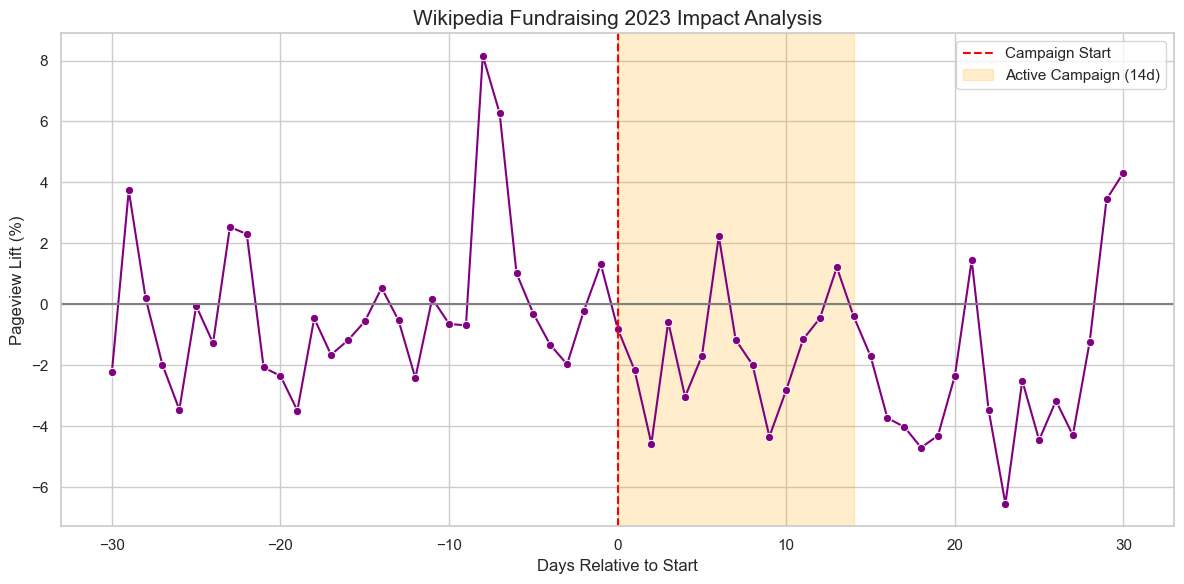

In [5]:
def plot_event(event_data, title):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=event_data, x='relative_day', y='percent_lift', marker='o', color='purple')
    
    # Reference lines
    plt.axvline(x=0, color='red', linestyle='--', label='Campaign Start')
    plt.axvspan(0, 14, color='orange', alpha=0.2, label='Active Campaign (14d)')
    plt.axhline(y=0, color='gray', linestyle='-')
    
    plt.title(title, fontsize=15)
    plt.xlabel('Days Relative to Start', fontsize=12)
    plt.ylabel('Pageview Lift (%)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

if example_event is not None:
    plot_event(example_event, 'Wikipedia Fundraising 2023 Impact Analysis')
else:
    print("Not enough data for the example window.")

### Observation

Across the entire event window:

The percent lift fluctuates around zero

The majority of values fall within ±4%

There is no sustained positive deviation during the campaign period

### Interpretation

The fundraising campaign does not produce a strong observable signal in overall pageview traffic.

Traffic behavior remains largely consistent with normal fluctuations seen in the baseline period.

Key Insight

The data suggests that Wikipedia fundraising campaigns may not significantly influence total pageview volume.

This is consistent with the nature of the campaign: fundraising banners primarily target existing users already visiting the site, rather than attracting new traffic.

Therefore, the campaign’s primary objective is likely donation conversion rather than traffic generation.

C:\Users\preet\AppData\Local\Temp\ipykernel_25228\88944443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=event_data,


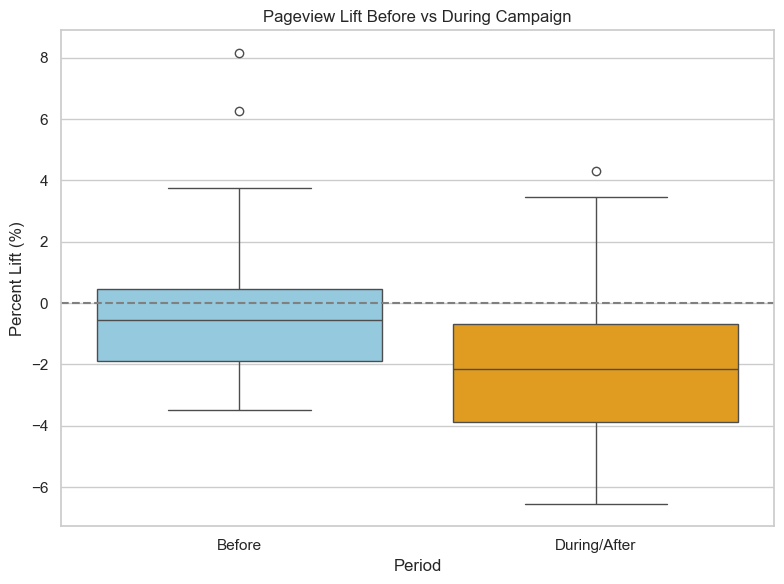

In [6]:
def plot_before_after(event_data):

    event_data['period'] = event_data['relative_day'].apply(
        lambda x: 'Before' if x < 0 else 'During/After'
    )

    plt.figure(figsize=(8,6))

    sns.boxplot(data=event_data,
                x='period',
                y='percent_lift',
                palette=['skyblue','orange'])

    plt.axhline(0, color='gray', linestyle='--')

    plt.title('Pageview Lift Before vs During Campaign')
    plt.xlabel('Period')
    plt.ylabel('Percent Lift (%)')

    plt.tight_layout()
    plt.show()
plot_before_after(example_event)

The boxplot comparison shows a clear downward shift in pageview lift during the campaign period. The median lift declines from approximately -0.5% before the campaign to roughly -2% during and after the campaign. Additionally, the entire interquartile range during the campaign lies below zero, indicating that pageviews were generally lower than expected throughout this period. However, the magnitude of these deviations remains relatively small, suggesting that the fundraising campaign has limited impact on overall site traffic.

## 4. Cross-Campaign Comparison
Now we across multiple years and campaign types.

In [ ]:
all_results = []

for campaign_type, dates in campaign_config.items():
    for year, date_str in dates.items():
        event_df = analyze_campaign(df, date_str, campaign_type, year)
        if event_df is not None:
            # Compute metrics
            active_mask = (event_df['relative_day'] >= 0) & (event_df['relative_day'] <= 14)
            post_mask = (event_df['relative_day'] > 14)
            
            all_results.append({
                'Campaign': campaign_type,
                'Year': year,
                'Avg Lift (%)': event_df.loc[active_mask, 'percent_lift'].mean(),
                'Peak Lift (%)': event_df.loc[active_mask, 'percent_lift'].max(),
                'Post Residual (%)': event_df.loc[post_mask, 'percent_lift'].mean()
            })

comparison_df = pd.DataFrame(all_results)
comparison_df.sort_values(by='Avg Lift (%)', ascending=False).head(10)
comparison_df.to_csv('campaign_comparison.csv', index=False)

,Campaign,Year,Avg Lift (%),Peak Lift (%),Post Residual (%)
27,wikipedia_asian_month,2020,12.277613,21.511448,9.433921
18,wiki_loves_monuments,2022,10.467090,20.823978,7.412331
23,wikipedia_asian_month,2016,6.741588,10.228233,4.472293
37,wiki_loves_earth,2020,6.713248,12.759989,-0.965828
11,wiki_loves_monuments,2015,5.390103,13.569688,-0.145732
24,wikipedia_asian_month,2017,5.388880,7.790159,4.841730
26,wikipedia_asian_month,2019,4.605035,10.518000,2.228092
21,wiki_loves_monuments,2025,4.225017,8.916476,-0.455311
1,fundraising,2016,3.916664,7.214393,-0.300178
31,wikipedia_asian_month,2024,3.595428,16.583210,2.293918


## 5. Summary Visualization: Campaign Type Comparison

C:\Users\preet\AppData\Local\Temp\ipykernel_32264\2631797167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Campaign', y='Avg Lift (%)', palette='Set2')


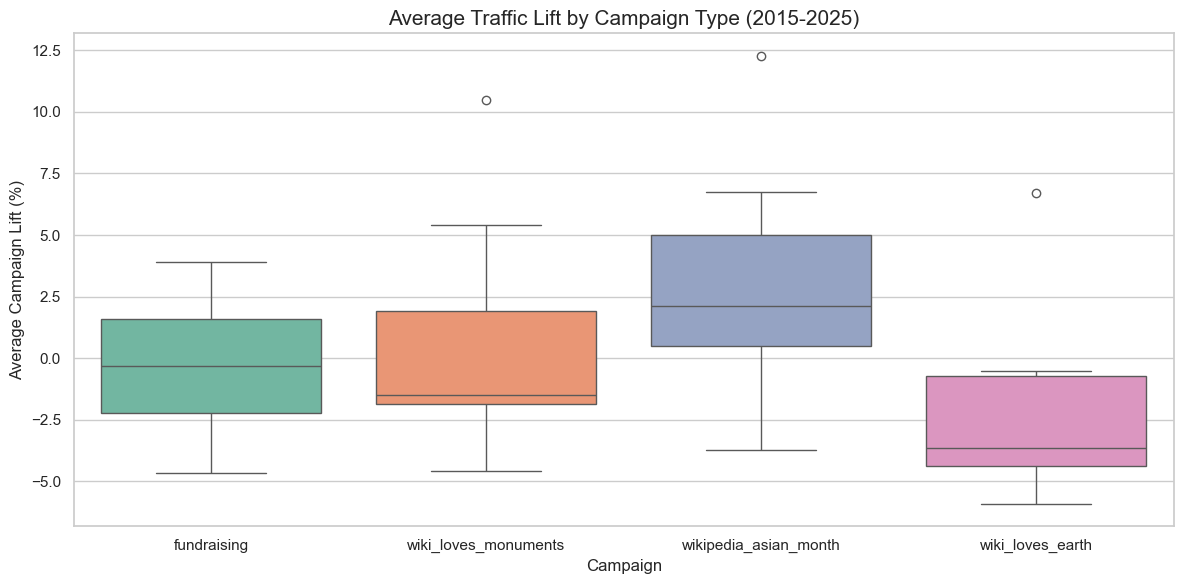

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=comparison_df, x='Campaign', y='Avg Lift (%)', palette='Set2')
plt.title('Average Traffic Lift by Campaign Type (2015-2025)', fontsize=15)
plt.ylabel('Average Campaign Lift (%)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_3_campaign_comparison.png'))
plt.show()

Important observation is difference in variability.

Wikipedia Asian Month → moderate variability but mostly positive

Wiki Loves Monuments → highest variability

Fundraising → relatively stable distribution

Wiki Loves Earth → consistently negative

### Insight

This suggests that some campaigns produce predictable engagement outcomes, while others experience year-to-year variability depending on external participation levels or event visibility.

## Overall Conclusion

Across all campaign types, pageview lift generally remains within a relatively narrow range (approximately -6% to +7%), indicating that campaign effects on total Wikipedia traffic are moderate rather than dramatic.

However, the comparison reveals that community-driven content campaigns such as Wikipedia Asian Month appear to generate stronger engagement signals than fundraising or photography campaigns.